<a href="https://colab.research.google.com/github/SHaruto0/CSCI-4170-Project-in-AI-and-ML/blob/main/HW4/Haruto_Suzuki_HW4_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis on the PDF

# TASK 1

## Dataset

[Microsoft Stock- Time Series Analysis](https://www.kaggle.com/datasets/vijayvvenkitesh/microsoft-stock-time-series-analysis?resource=download)

Predicting the next day’s closing price requires sequence models because stock data is temporally dependent—today’s price is influenced by patterns and trends over previous days. RNN-based architectures (like LSTM/GRU) are ideal since they can capture these temporal dependencies and evolving patterns far better than non-sequential models.

## Import Libraries

In [148]:
import torch
import torch.nn as nn

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [149]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [150]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## Process Data

In [151]:
!unzip /content/data.zip

Archive:  /content/data.zip
  inflating: Microsoft_Stock.csv     


In [152]:
df = pd.read_csv("Microsoft_Stock.csv")

In [153]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date just in case
df = df.sort_values(by='Date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1511 non-null   datetime64[ns]
 1   Open    1511 non-null   float64       
 2   High    1511 non-null   float64       
 3   Low     1511 non-null   float64       
 4   Close   1511 non-null   float64       
 5   Volume  1511 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 71.0 KB


### Visualize Stock Prices

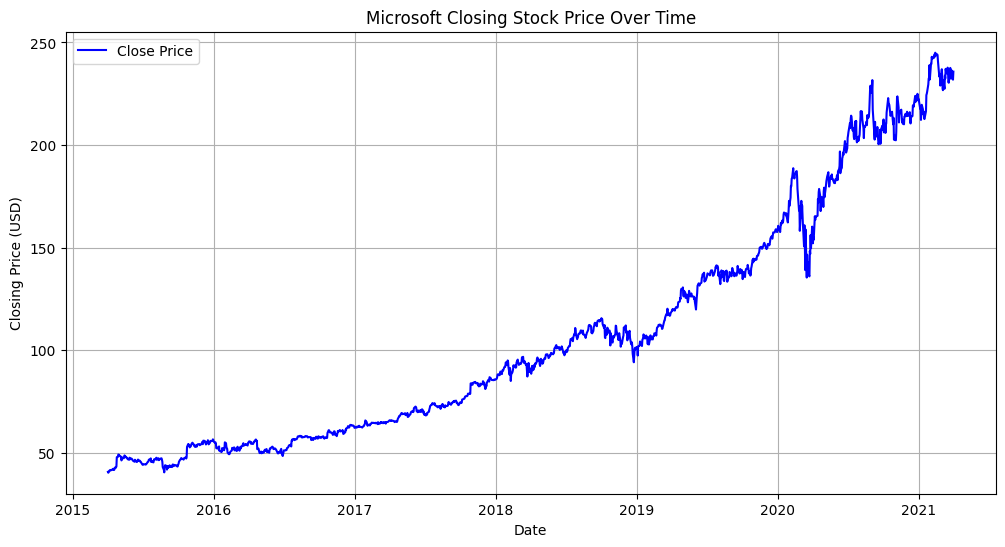

In [154]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title("Microsoft Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("microsoft_closing_price.png")
plt.show()

The following graph shows the number of Microsoft shares traded each day over time. It highlights periods of increased or decreased trading activity, which can signal market reactions to news, earnings, or other significant events.

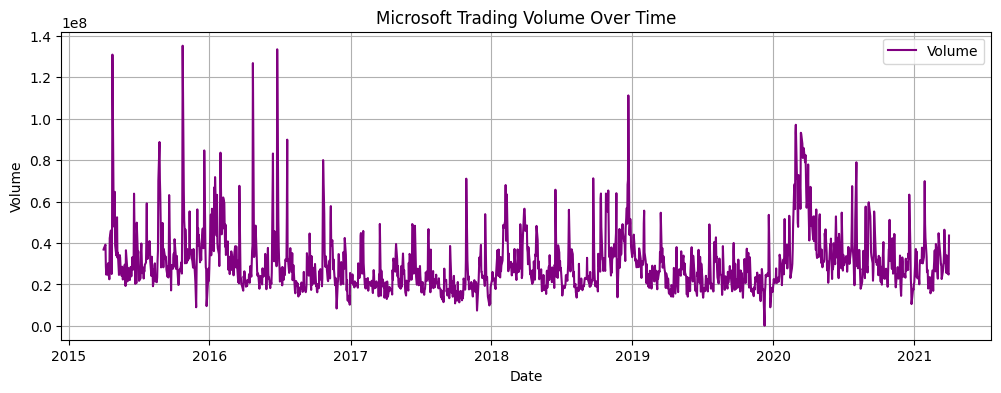

In [155]:
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Volume'], label='Volume', color='purple')
plt.title("Microsoft Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.savefig("microsoft_trading_volume.png")
plt.show()

The following graph is all the input visualized on one graph between the year of 2020 and 2021. All four graph follows the same trend throughout the data.

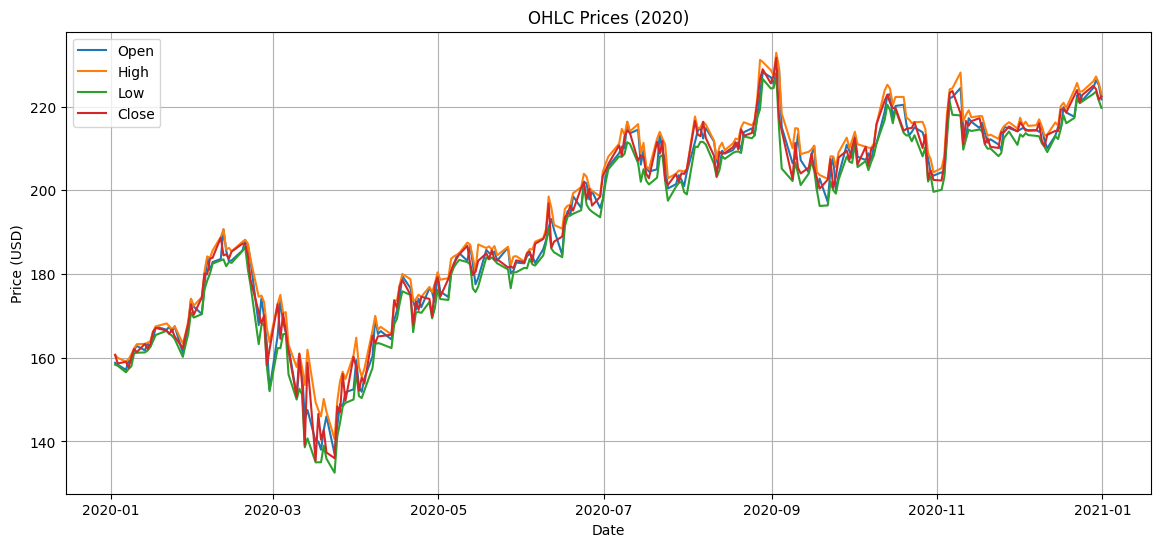

In [247]:
# Filter data between 2020 and 2021
mask = (df['Date'] >= '2020-01-01') & (df['Date'] <= '2021-01-01')
df_zoom = df.loc[mask]

# Plot OHLC for filtered date range
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df_zoom['Date'], df_zoom[col], label=col)
plt.title("OHLC Prices (2020)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("microsoft_ohlc_prices_2020.png")
plt.show()

### Train Data

Scale it and put back Data column for graphing later

In [157]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target = 'Close'

scaler = MinMaxScaler()

# Fit and transform features
scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df['Date'] = df['Date'].values

Generate input data using a sliding window approach, where each sample consists of 60 consecutive days of input features and the target is the closing price on the 61st day

In [158]:
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_df)):
    X.append(scaled_df[features].iloc[i-sequence_length:i].values)
    y.append(scaled_df[target].iloc[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # Should be (num_samples, 60, 5)
print("y shape:", y.shape)  # Should be (num_samples,)

X shape: (1451, 60, 5)
y shape: (1451,)


In [159]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1015, 60, 5)
Val: (218, 60, 5)
Test: (218, 60, 5)


Convert to tensor and put it do appropriate device

In [160]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)
X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)

## Train Function

Since the structure will be kept the same

In [161]:
def train(name, model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs=50):
  train_losses, val_losses = [], []

  for epoch in range(1, epochs + 1):
      model.train()
      output = model(X_train_t)
      loss = criterion(output, y_train_t)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

      # Validation
      model.eval()
      with torch.no_grad():
          val_output = model(X_val_t)
          val_loss = criterion(val_output, y_val_t).item()

      # Store metrics
      train_losses.append(loss.item())
      val_losses.append(val_loss)

      # Print every 5 epochs
      if epoch % 5 == 0 or epoch == 1:
          print(f"Epoch {epoch}/{epochs} \t Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

  # Save model
  torch.save(model.state_dict(), "rnn_stock_model.pth")
  print("Model saved as rnn_stock_model.pth")

  plt.figure(figsize=(12, 6))
  plt.plot(train_losses, label='Training Loss', color='blue')
  plt.plot(val_losses, label='Validation Loss', color='red')
  plt.title(f"Training and Validation Loss for {name}")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.grid(True)
  plt.legend()
  plt.savefig(f"{name}_loss_plot.png")
  plt.show()

## Test Function

In [162]:
def test(name, model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        test_output = model(X_test).cpu().numpy()
        actual = y_test.cpu().numpy()
        test_loss = criterion(torch.tensor(test_output), y_test).item()
        predicted_values = test_output

    print(f"Test Loss for {name}: {test_loss:.4f}")

    # Plot Actual vs Predicted
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual', color='blue')
    plt.plot(predicted_values, label='Predicted', color='red')
    plt.title(f"Actual vs Predicted Closing Price ({name})")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Close Price")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{name}_predicted.png")
    plt.show()

## RNN Architecture

In [199]:
class RNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=50, num_layers=1):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)  # Output: closing price

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        return self.fc(out[:, -1, :])  # Use last hidden state to predict the closing price of 61st day

In [200]:
RNNmodel = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(RNNmodel.parameters(), lr=0.001)

RNNmodel.to(device)

RNN(
  (rnn): RNN(5, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

### RNN Train

Epoch 1/50 	 Train Loss: 0.2139 | Val Loss: 0.6003
Epoch 5/50 	 Train Loss: 0.0944 | Val Loss: 0.3474
Epoch 10/50 	 Train Loss: 0.0210 | Val Loss: 0.1352
Epoch 15/50 	 Train Loss: 0.0114 | Val Loss: 0.0329
Epoch 20/50 	 Train Loss: 0.0174 | Val Loss: 0.0235
Epoch 25/50 	 Train Loss: 0.0084 | Val Loss: 0.0488
Epoch 30/50 	 Train Loss: 0.0070 | Val Loss: 0.0741
Epoch 35/50 	 Train Loss: 0.0074 | Val Loss: 0.0713
Epoch 40/50 	 Train Loss: 0.0053 | Val Loss: 0.0491
Epoch 45/50 	 Train Loss: 0.0041 | Val Loss: 0.0291
Epoch 50/50 	 Train Loss: 0.0036 | Val Loss: 0.0202
Model saved as rnn_stock_model.pth


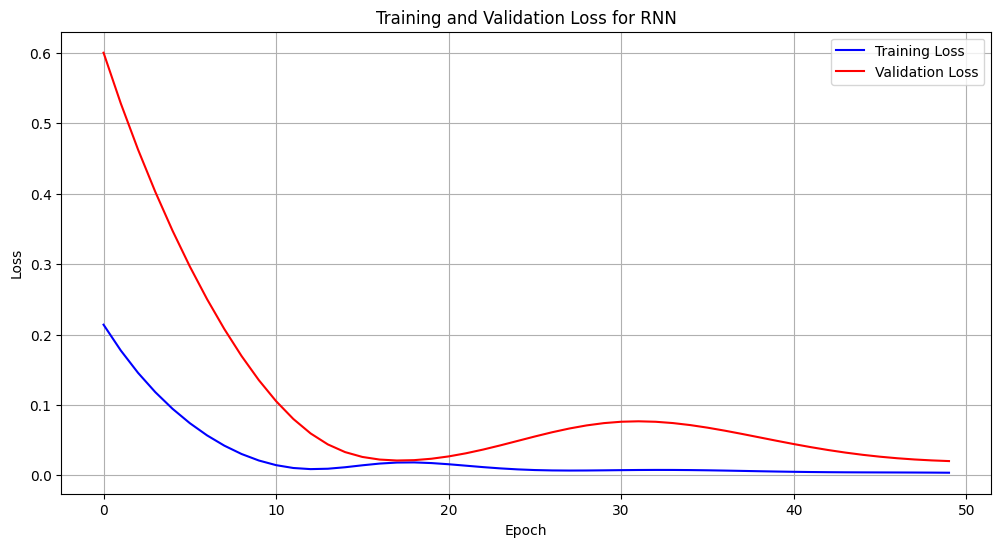

In [201]:
train("RNN", RNNmodel, criterion, optimizer, X_train_t, y_train_t, X_val_t, y_val_t)

### RNN Test

Test Loss for RNN: 0.0827


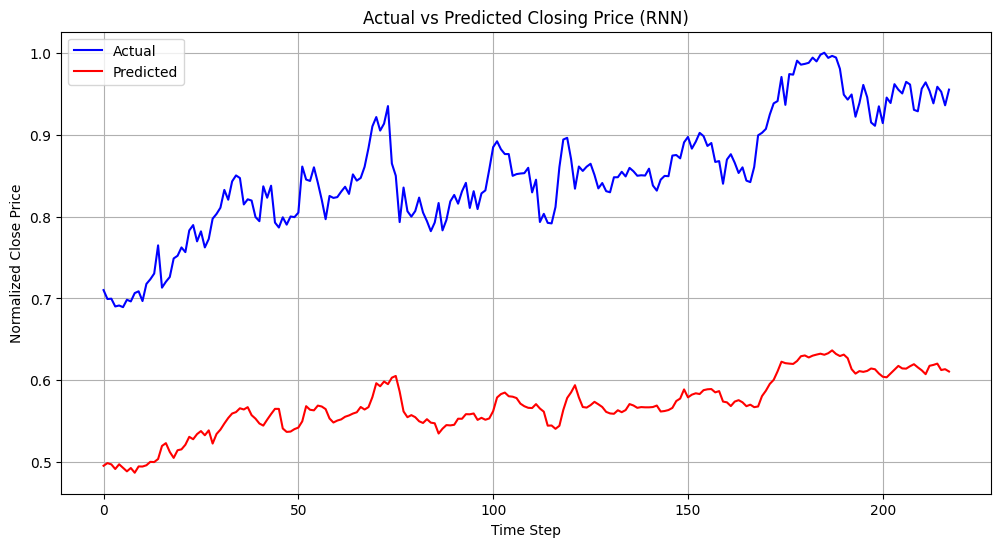

In [202]:
test("RNN", RNNmodel, X_test_t, y_test_t)

## LSTM Architecture

In [203]:
class LSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=50, num_layers=1):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [204]:
LSTMmodel = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(LSTMmodel.parameters(), lr=0.001)

LSTMmodel.to(device)

LSTM(
  (lstm): LSTM(5, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

### LSTM Train

Epoch 1/50 	 Train Loss: 0.0928 | Val Loss: 0.3816
Epoch 5/50 	 Train Loss: 0.0582 | Val Loss: 0.2846
Epoch 10/50 	 Train Loss: 0.0277 | Val Loss: 0.1771
Epoch 15/50 	 Train Loss: 0.0100 | Val Loss: 0.0824
Epoch 20/50 	 Train Loss: 0.0093 | Val Loss: 0.0247
Epoch 25/50 	 Train Loss: 0.0102 | Val Loss: 0.0216
Epoch 30/50 	 Train Loss: 0.0062 | Val Loss: 0.0386
Epoch 35/50 	 Train Loss: 0.0054 | Val Loss: 0.0492
Epoch 40/50 	 Train Loss: 0.0050 | Val Loss: 0.0432
Epoch 45/50 	 Train Loss: 0.0036 | Val Loss: 0.0250
Epoch 50/50 	 Train Loss: 0.0024 | Val Loss: 0.0073
Model saved as rnn_stock_model.pth


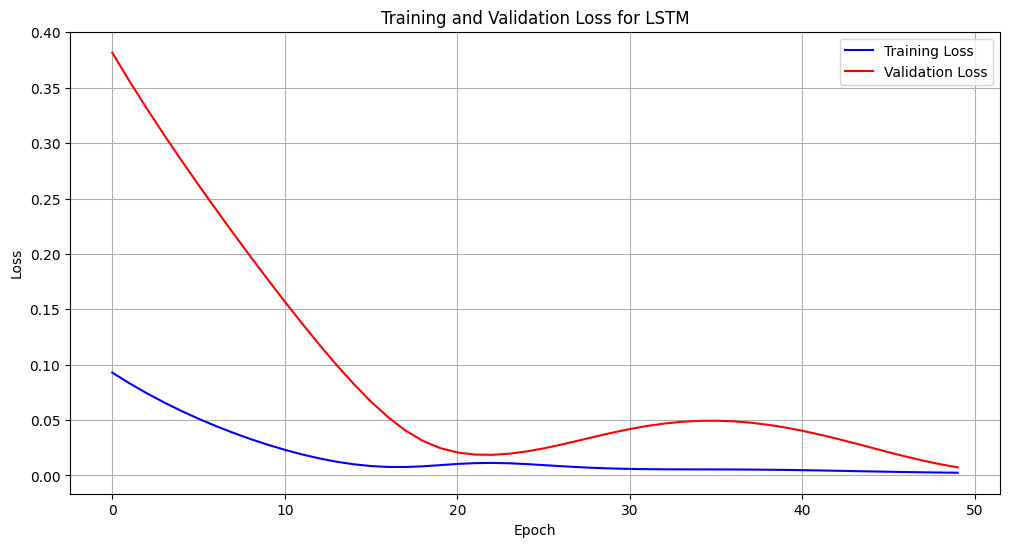

In [205]:
train("LSTM", LSTMmodel, criterion, optimizer, X_train_t, y_train_t, X_val_t, y_val_t)

### LSTM Test

Test Loss for LSTM: 0.0207


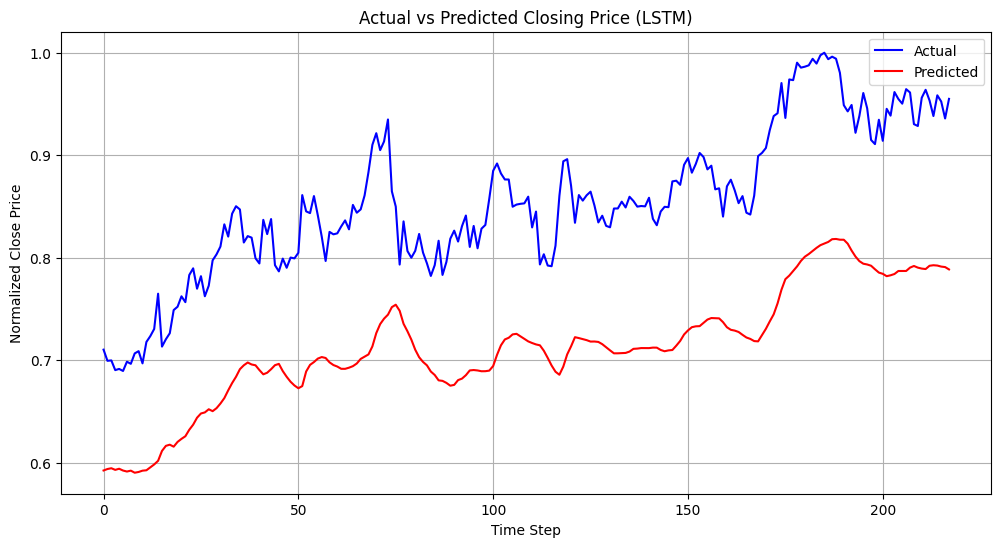

In [206]:
test("LSTM", LSTMmodel, X_test_t, y_test_t)

## GRU Architecture

In [215]:
class GRU(nn.Module):
    def __init__(self, input_size=5, hidden_size=50, num_layers=1):
        super(GRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [216]:
GRUmodel = GRU()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(GRUmodel.parameters(), lr=0.001)

GRUmodel.to(device)

GRU(
  (gru): GRU(5, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

### GRU Train

Epoch 1/50 	 Train Loss: 0.1283 | Val Loss: 0.4326
Epoch 5/50 	 Train Loss: 0.0761 | Val Loss: 0.2919
Epoch 10/50 	 Train Loss: 0.0292 | Val Loss: 0.1463
Epoch 15/50 	 Train Loss: 0.0058 | Val Loss: 0.0447
Epoch 20/50 	 Train Loss: 0.0079 | Val Loss: 0.0067
Epoch 25/50 	 Train Loss: 0.0088 | Val Loss: 0.0069
Epoch 30/50 	 Train Loss: 0.0040 | Val Loss: 0.0197
Epoch 35/50 	 Train Loss: 0.0031 | Val Loss: 0.0324
Epoch 40/50 	 Train Loss: 0.0033 | Val Loss: 0.0342
Epoch 45/50 	 Train Loss: 0.0026 | Val Loss: 0.0260
Epoch 50/50 	 Train Loss: 0.0017 | Val Loss: 0.0152
Model saved as rnn_stock_model.pth


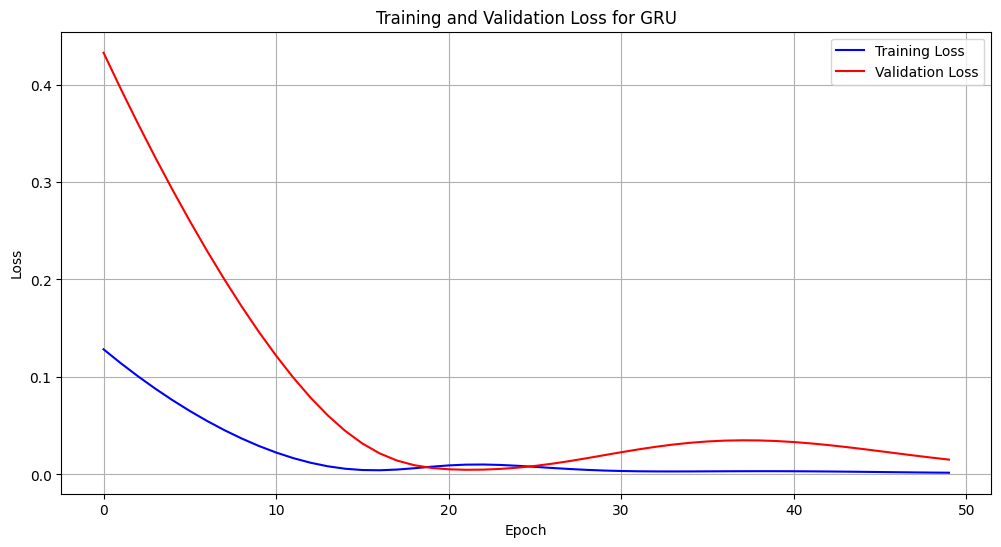

In [217]:
train("GRU", GRUmodel, criterion, optimizer, X_train_t, y_train_t, X_val_t, y_val_t)

### GRU Test

Test Loss for GRU: 0.0525


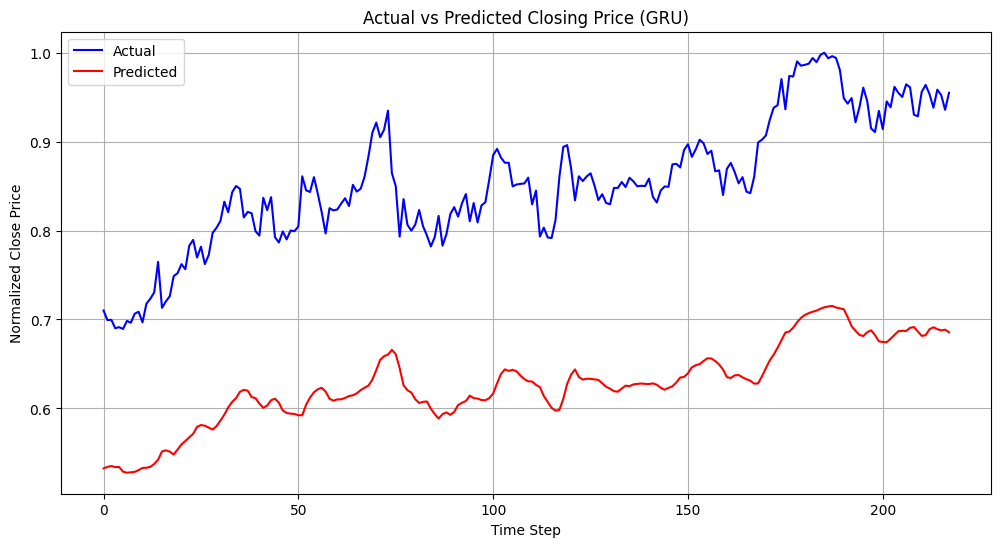

In [218]:
test("GRU", GRUmodel, X_test_t, y_test_t)

# Task 2

## Import Libraries

In [223]:
# BERT Embedding with Hugging Face
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from transformers import BertTokenizer, BertModel

## Test Embedding

In [227]:
# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")
model.eval()

def get_word_embedding(word):
    tokens = tokenizer.tokenize(word)
    ids = tokenizer.convert_tokens_to_ids(tokens)
    input_ids = torch.tensor([ids])

    with torch.no_grad():
        outputs = model(input_ids)
        hidden_states = outputs.last_hidden_state.squeeze(0)

    # Average subword embeddings if multiple tokens
    if hidden_states.shape[0] > 1:
        embedding = hidden_states.mean(dim=0)
    else:
        embedding = hidden_states[0]

    return embedding, tokens

# User input
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")
print()

embedding1, tokens1 = get_word_embedding(word1)
embedding2, tokens2 = get_word_embedding(word2)

print(f"Embedding for '{word1}' (tokens: {tokens1}):\n", embedding1)
print()
print(f"Embedding for '{word2}' (tokens: {tokens2}):\n", embedding2)

Enter first word: HEllO!!!
Enter second word: WORlD

Embedding for 'HEllO!!!' (tokens: ['hello', '!', '!', '!']):
 tensor([ 3.2631e-01,  3.8164e-01, -2.7018e-01, -7.8328e-01, -5.8508e-01,
         4.9932e-01,  2.8470e-01, -2.2698e-01, -3.1687e-01, -5.9629e-01,
        -4.3139e-01, -6.5792e-01, -7.6308e-01,  5.2640e-02,  1.3636e-01,
         8.1473e-01, -1.9880e-01, -4.5409e-01,  1.0709e-01,  7.1889e-01,
         1.6555e-01, -1.8564e-01,  1.0474e-01, -3.1057e-01,  6.0449e-01,
        -6.8471e-01,  7.3995e-01,  5.5995e-01, -5.2091e-01, -7.0672e-01,
         2.1654e-01, -8.0147e-01,  6.2118e-01, -2.7365e-01,  3.2603e-01,
        -9.4169e-02,  3.0572e-01,  2.3035e-01,  1.7360e-01, -4.5248e-01,
        -2.3766e-02, -1.1599e-01,  7.7147e-01,  7.0712e-02,  1.4094e-01,
        -2.5208e-01,  3.9505e-02, -9.3551e-02, -5.7460e-01, -2.5907e-01,
         1.6387e-01,  3.2646e-01,  4.3942e-01,  1.9784e-01,  5.3931e-02,
         4.1402e-01, -6.2933e-01, -3.7265e-01, -8.1618e-01, -7.3298e-02,
         

## Cosine Similarity and PCA Visual

Cosine similarity between 'king' and 'queen': 0.6095
Cosine similarity between 'cat' and 'dog': 0.6345
Cosine similarity between 'car' and 'banana': 0.5571
Cosine similarity between 'table' and 'apple': 0.4566


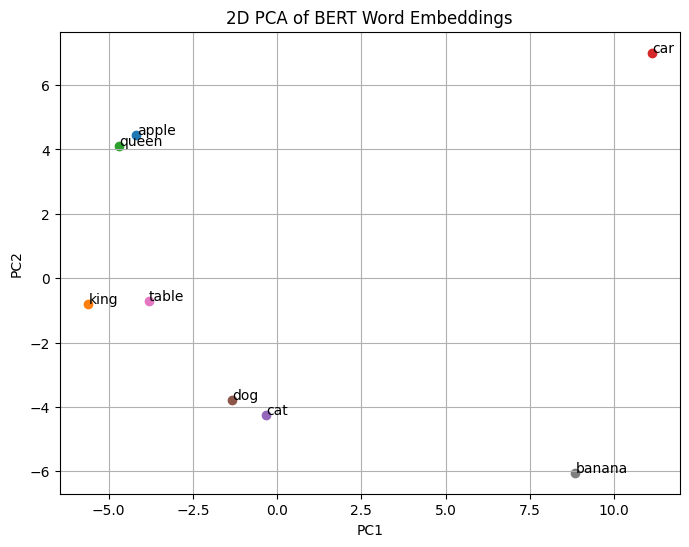

In [225]:
# Load BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")
model.eval()

def get_embedding(word):
    tokens = tokenizer.tokenize(word)
    ids = tokenizer.convert_tokens_to_ids(tokens)
    input_ids = torch.tensor([ids])
    with torch.no_grad():
        output = model(input_ids)
        hidden = output.last_hidden_state.squeeze(0)
    return hidden.mean(dim=0) if hidden.shape[0] > 1 else hidden[0]

def cosine_similarity(a, b):
    return torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

# Batch input
word_pairs = [("king", "queen"), ("cat", "dog"), ("car", "banana"), ("table", "apple")]
similarities = []

for w1, w2 in word_pairs:
    e1, e2 = get_embedding(w1), get_embedding(w2)
    sim = cosine_similarity(e1, e2)
    similarities.append((w1, w2, sim))
    print(f"Cosine similarity between '{w1}' and '{w2}': {sim:.4f}")

# Visualization with PCA
all_words = list(set([w for pair in word_pairs for w in pair]))
embeddings = [get_embedding(w).numpy() for w in all_words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for i, word in enumerate(all_words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)
plt.title("2D PCA of BERT Word Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.savefig("bert_pca.png")
plt.show()

### User Choice

In [236]:
w1 = input("Input word 1: ")
w2 = input("Input word 2: ")
print()

e1, e2 = get_embedding(w1), get_embedding(w2)
sim = cosine_similarity(e1, e2)
similarities.append((w1, w2, sim))
print(f"Cosine similarity between '{w1}' and '{w2}': {sim:.4f}")

Input word 1: school
Input word 2: country

Cosine similarity between 'school' and 'country': 0.2792


## Try Other Similarity/Dissimilarity Metrics

euclidean [('cat', np.float32(0.0)), ('dog', np.float32(11.856995)), ('tiger', np.float32(12.64764)), ('king', np.float32(13.398368)), ('table', np.float32(13.541243))]
cosine [('cat', -1.1920928955078125e-07), ('dog', 0.3654986619949341), ('lion', 0.40658462047576904), ('tiger', 0.466092050075531), ('king', 0.4833866357803345)]
manhattan [('cat', np.float32(0.0)), ('dog', np.float32(260.81387)), ('tiger', np.float32(276.11594)), ('table', np.float32(293.3105)), ('king', np.float32(298.87518))]


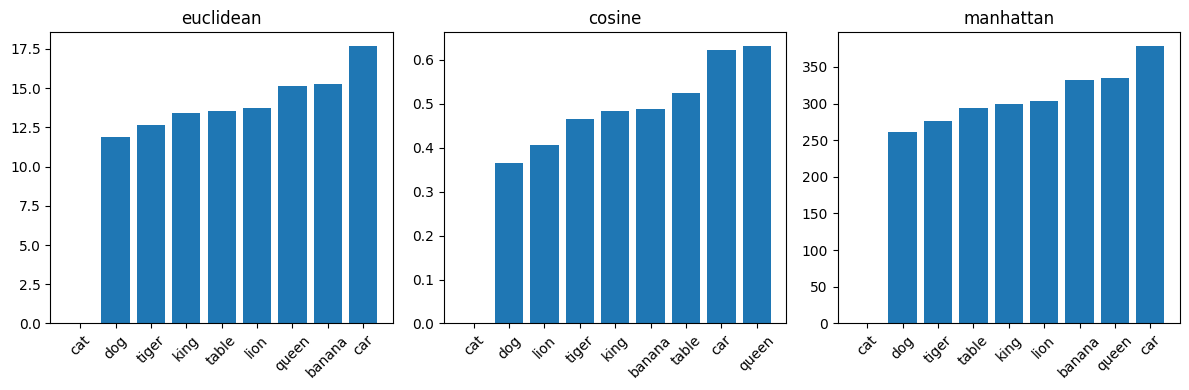

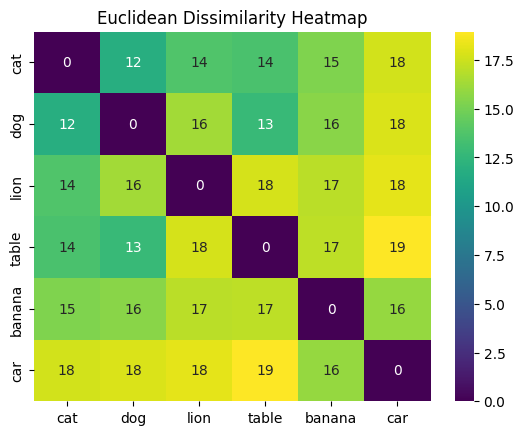

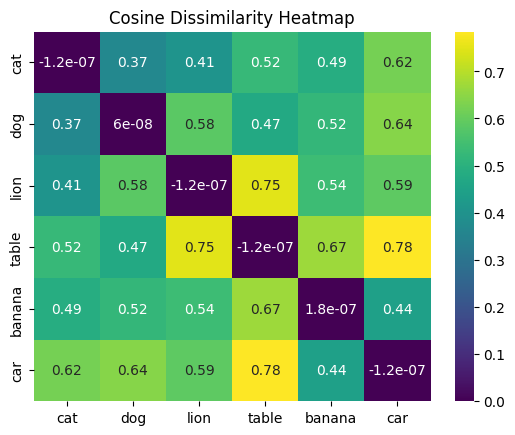

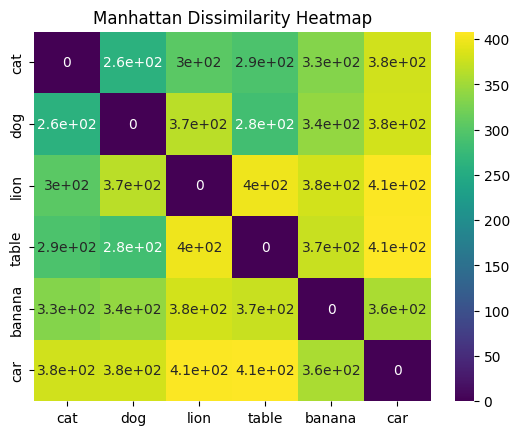

In [243]:
word_list = ["cat", "dog", "lion", "tiger", "table", "banana", "car", "queen", "king"]
# word_list = [
#     "cat", "dog", "lion", "tiger", "wolf",
#     "king", "queen", "man", "woman",
#     "apple", "banana", "grape", "carrot",
#     "car", "truck", "bus", "train", "bicycle",
#     "table", "chair", "sofa", "bed",
#     "city", "village", "forest", "desert",
#     "love", "war", "peace", "anger",
#     "math", "science", "art", "music"
# ]

# Precomputed embeddings dict: {word: np.array}
embeddings = {w: get_embedding(w).numpy() for w in word_list}

def dissimilarity(a, b, metric="euclidean"):
    a = torch.tensor(a) if isinstance(a, np.ndarray) else a
    b = torch.tensor(b) if isinstance(b, np.ndarray) else b

    if metric == "euclidean":
        return np.linalg.norm(a.numpy() - b.numpy())
    elif metric == "cosine":
        return 1 - torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()
    elif metric == "manhattan":
        return np.sum(np.abs(a.numpy() - b.numpy()))

# Ranking words by dissimilarity to "cat"
target = embeddings["cat"]
scores = {metric: sorted([(w, dissimilarity(target, vec, metric))
                          for w, vec in embeddings.items()],
                          key=lambda x: x[1])
          for metric in ["euclidean", "cosine", "manhattan"]}

for metric, ranked in scores.items():
    print(metric, ranked[:5])

# Plot rankings
plt.figure(figsize=(12, 4))
for i, metric in enumerate(scores):
    plt.subplot(1, 3, i+1)
    words, vals = zip(*scores[metric])
    plt.bar(words[:10], vals[:10])
    plt.title(metric)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("dissimilarity_rankings.png")
plt.show()

# Word list for heatmap
words = ["cat", "dog", "lion", "table", "banana", "car"]
# words = [
#     "cat", "dog", "lion", "tiger", "wolf",
#     "king", "queen", "man", "woman",
#     "apple", "banana", "grape", "carrot",
#     "car", "truck", "bus", "train", "bicycle",
#     "table", "chair", "sofa", "bed",
#     "city", "village", "forest", "desert",
#     "love", "war", "peace", "anger",
#     "math", "science", "art", "music"
# ]

def heatmap(name):
  # Create empty matrix
  mat = np.zeros((len(words), len(words)))

  # Fill matrix with dissimilarity scores
  for i, w1 in enumerate(words):
      for j, w2 in enumerate(words):
          mat[i, j] = dissimilarity(embeddings[w1], embeddings[w2], metric=name.lower())

  # Plot heatmap
  sns.heatmap(mat, annot=True, xticklabels=words, yticklabels=words, cmap="viridis")
  plt.title(f"{name} Dissimilarity Heatmap")
  plt.savefig(f"{name}_heatmap.png")
  plt.show()

heatmap("Euclidean")
heatmap("Cosine")
heatmap("Manhattan")

### User Choice

In [246]:
measure = input("Select a measure (euclidean, cosine, manhattan). Case sensitive: ")
print()

w1 = input("Input word 1: ")
w2 = input("Input word 2: ")
print()

e1, e2 = get_embedding(w1), get_embedding(w2)
sim = dissimilarity(e1, e2, measure)
print(f"Dissimilarity between '{w1}' and '{w2}': {sim:.4f}")

Select a measure (euclidean, cosine, manhattan). Case sensitive: manhattan

Input word 1: cat
Input word 2: dog

Dissimilarity between 'cat' and 'dog': 260.8139
